<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/US_Solar_Data_Analysis_%2C_Prediction_and_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Solar Power Forecasting and Analysis**

**Dataset Link:** https://www.kaggle.com/datasets/suvijyaarya/pvdaq-photovoltaic-datausa-2019-2023

### **Dataset Overview**
* The PVDAQ (Photovoltaic Data Acquisition) Dataset (USA, 2019–2023) contains historical operational and environmental data collected from photovoltaic (PV) solar energy systems across the United States. The dataset is derived from the National Renewable Energy Laboratory (NREL) PVDAQ database, which monitors the performance of solar power systems under various weather and environmental conditions.

* The dataset includes time-series measurements such as:


1.   Solar power generatio
2.   Solar irradiance
3.   Ambient and module temperature
4. Wind speed
5. Weather-related variables
6. System performance metrics
7. Timestamp information (date and time)

* These variables provide valuable insights into how environmental conditions influence photovoltaic system performance and energy generation. The dataset is well suited for data analysis, visualization, regression, forecasting, and machine learning applications.

In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (2).zip'

# Create a directory to extract to, if it doesn't exist
extract_dir = '/content/unzipped_data'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Successfully unzipped {zip_file_path} to {extract_dir}')

Successfully unzipped /content/archive (2).zip to /content/unzipped_data


In [ ]:
# List the contents of the unzipped directory to identify data files
print('Contents of unzipped_data directory:')
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of unzipped_data directory:
/content/unzipped_data/pvdaq_system10_2019_2023_combined.csv


In [ ]:
import pandas as pd

data_file_path = '/content/unzipped_data/pvdaq_system10_2019_2023_combined.csv'
df = pd.read_csv(data_file_path)


df.head()

,measured_on,ac_power__423,ac_voltage__426,das_temp__433,dc_pos_voltage__424,dc_power__422,module_temp_1__429,module_temp_3__431,poa_irradiance__421,system_id,source_file,module_temp_2__430,inverter_temp__432,dc_pos_current__425,ac_current__427,ambient_temp__428,das_battery_voltage__434
0,2019-01-10 00:29:00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,10,system_10__date_2019_01_10.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-10 00:36:00,NaN,122.0,NaN,NaN,NaN,NaN,NaN,NaN,10,system_10__date_2019_01_10.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-10 01:02:00,NaN,122.0,NaN,NaN,NaN,NaN,NaN,NaN,10,system_10__date_2019_01_10.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-10 01:18:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10,system_10__date_2019_01_10.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-10 01:39:00,NaN,122.0,NaN,NaN,NaN,NaN,NaN,NaN,10,system_10__date_2019_01_10.csv,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['measured_on', 'ac_power__423', 'ac_voltage__426', 'das_temp__433',
       'dc_pos_voltage__424', 'dc_power__422', 'module_temp_1__429',
       'module_temp_3__431', 'poa_irradiance__421', 'system_id', 'source_file',
       'module_temp_2__430', 'inverter_temp__432', 'dc_pos_current__425',
       'ac_current__427', 'ambient_temp__428', 'das_battery_voltage__434'],
      dtype='object')

In [ ]:
df.shape

(1988017, 17)

In [ ]:
column_mapping = {
        "measured_on": "timestamp",
        "poa_irradiance__421": "poa_irradiance",
        "dc_power__422": "dc_power",
        "ac_power__423": "ac_power",
        "dc_pos_voltage__424": "dc_voltage",
        "dc_pos_current__425": "dc_current",
        "ac_voltage__426": "ac_voltage",
        "ac_current__427": "ac_current",
        "ambient_temp__428": "ambient_temp",
        "module_temp_1__429": "module_temp_1",
        "module_temp_2__430": "module_temp_2",
        "module_temp_3__431": "module_temp_3",
        "inverter_temp__432": "inverter_temp",
        "das_temp__433": "das_temp",
        "das_battery_voltage__434": "das_battery_voltage",
    }
df = df.rename(columns=column_mapping)

In [ ]:
df.describe()

,ac_power,ac_voltage,das_temp,dc_voltage,dc_power,module_temp_1,module_temp_3,poa_irradiance,system_id,module_temp_2,inverter_temp,dc_current,ac_current,ambient_temp,das_battery_voltage
count,1.983483e+06,1.984010e+06,1.983050e+06,1.983637e+06,1.984181e+06,1.977827e+06,1.977580e+06,1.900578e+06,1988017.0,1.977581e+06,1.977566e+06,1.983043e+06,1.983037e+06,1.983034e+06,1.983042e+06
mean,1.809685e+02,1.204373e+02,1.573954e+01,9.979320e+01,2.239087e+02,1.724534e+01,1.823229e+01,2.332440e+02,10.0,1.756731e+01,1.638276e+01,1.048981e+00,2.714369e+00,1.194894e+01,1.308378e+01
std,2.877394e+02,7.177662e+00,1.282509e+01,1.017026e+02,3.506079e+02,1.697782e+01,1.838560e+01,4.063933e+02,0.0,1.752367e+01,1.532982e+01,1.665693e+00,1.891408e+00,1.105157e+01,9.876306e-01
min,-1.313000e+02,-1.619600e+01,-2.121700e+01,-6.474100e+01,-1.762800e+01,-2.426600e+01,-2.365400e+01,-5.308900e+03,10.0,-2.352200e+01,-2.413200e+01,-1.077200e+00,-2.693600e+00,-2.543800e+01,1.000000e+00
25%,-1.109300e+00,1.192500e+02,5.813825e+00,-1.329000e-02,-1.090000e-03,3.877400e+00,3.934600e+00,-2.653300e+00,10.0,3.699600e+00,4.737300e+00,-2.360000e-02,1.639500e+00,3.553500e+00,1.308200e+01
50%,-5.089900e-01,1.206900e+02,1.517750e+01,4.316800e+01,6.084000e-02,1.523300e+01,1.545200e+01,2.625800e+00,10.0,1.525000e+01,1.489100e+01,1.827000e-02,1.680400e+00,1.229850e+01,1.325900e+01
75%,2.906200e+02,1.219300e+02,2.429600e+01,2.054500e+02,3.582500e+02,2.869700e+01,2.986500e+01,3.899900e+02,10.0,2.923800e+01,2.552800e+01,1.681900e+00,2.995100e+00,2.058200e+01,1.348900e+01
max,1.339500e+03,1.479000e+02,4.947600e+01,3.345500e+02,1.638500e+03,6.738800e+01,7.363300e+01,4.938000e+03,10.0,6.880600e+01,6.243400e+01,7.569500e+00,1.107800e+01,3.843000e+01,1.426000e+01


In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
timestamp,0
ac_power,4534
ac_voltage,4007
das_temp,4967
dc_voltage,4380
dc_power,3836
module_temp_1,10190
module_temp_3,10437
poa_irradiance,87439
system_id,0


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

## Handling missing values that causes by sensors using forward fill

In [ ]:
import numpy as np
# Forward-fill short gaps (<3 hours), then fill remaining with 0
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].ffill(limit=3).fillna(0)

In [ ]:
df.head(10)

,timestamp,ac_power,ac_voltage,das_temp,dc_voltage,dc_power,module_temp_1,module_temp_3,poa_irradiance,system_id,source_file,module_temp_2,inverter_temp,dc_current,ac_current,ambient_temp,das_battery_voltage
0,2019-01-03 00:52:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-01-03 01:58:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-01-03 02:03:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-01-03 02:46:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-01-03 03:31:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
5,2019-01-03 03:50:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
6,2019-01-03 05:43:00,0.0,121.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
7,2019-01-03 05:56:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
8,2019-01-03 07:57:00,0.0,122.0,0.0,0.0,0.0,0.0,0.0,266.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0
9,2019-01-03 08:15:00,350.0,122.0,0.0,0.0,0.0,0.0,0.0,266.0,10,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Engineering

In [ ]:
# Average panel surface temperature across 3 sensors
df["module_temp_avg"] = df[
        ["module_temp_1", "module_temp_2", "module_temp_3"]
    ].mean(axis=1)

# Thermal Delta
df["temp_delta"] = df["module_temp_avg"] - df["ambient_temp"]

# Inverter Efficiency Proxy (clipped between 0 and 1)
df["inverter_efficiency"] = np.where(
        df["dc_power"] > 0, df["ac_power"] / (df["dc_power"] + 1e-5), 0.0
    )
df["inverter_efficiency"] = np.clip(df["inverter_efficiency"], 0.0, 1.0)

# Cyclical Time Features
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)

# Effective Solar Production Index
df["effective_poa"] = df["poa_irradiance"] * (
        1.0 - (df["module_temp_avg"] - 25).clip(lower=0) * 0.004
    )

In [ ]:
df.sample(n=10)

,timestamp,ac_power,ac_voltage,das_temp,dc_voltage,dc_power,module_temp_1,module_temp_3,poa_irradiance,system_id,...,ambient_temp,das_battery_voltage,module_temp_avg,temp_delta,inverter_efficiency,hour,month,hour_sin,hour_cos,effective_poa
1527460,2022-04-10 02:05:00,-1.35270,119.61,7.6580,0.44740,-0.01304,5.84350,5.70780,0.0000,10,...,5.0531,13.467,5.679167,0.626067,0.000000,2,4,5.000000e-01,8.660254e-01,0.000000
1519796,2022-04-04 18:21:00,-1.07460,119.41,18.7730,23.52700,0.13918,15.39100,15.44600,2.0151,10,...,15.7460,13.227,15.426667,-0.319333,0.000000,18,4,-1.000000e+00,-1.836970e-16,2.015100
1876833,2022-12-08 20:35:00,-0.76535,118.37,2.0851,0.26588,-0.01299,-3.67160,-3.80720,-4.4405,10,...,0.2776,13.535,-3.743567,-4.021167,0.000000,20,12,-8.660254e-01,5.000000e-01,-4.440500
206778,2019-08-07 03:21:00,-0.47610,122.25,24.3020,-0.28309,0.00041,20.68100,20.72700,-3.6142,10,...,22.3160,13.126,20.718667,-1.597333,0.000000,3,8,7.071068e-01,7.071068e-01,-3.614200
1676839,2022-07-22 19:44:00,-0.94052,119.10,31.8900,3.05900,0.09367,26.06100,26.23100,-2029.9000,10,...,26.7970,13.032,26.175333,-0.621667,0.000000,19,7,-9.659258e-01,2.588190e-01,-2020.356763
607728,2020-07-04 12:03:00,214.37000,120.93,39.8160,210.45000,270.97000,39.33300,40.61900,258.2500,10,...,28.5690,12.939,39.856000,11.287000,0.791121,12,7,1.224647e-16,-1.000000e+00,242.903752
1233515,2021-09-14 23:00:00,-1.06350,119.77,16.7630,-0.90282,0.00547,12.81200,13.01000,-3.2578,10,...,14.9480,13.262,12.923333,-2.024667,0.000000,23,9,-2.588190e-01,9.659258e-01,-3.257800
637888,2020-07-25 17:36:00,19.83400,120.66,23.0480,202.96000,38.23300,22.34300,22.34900,54.6940,10,...,19.9940,13.126,22.344333,2.350333,0.518766,17,7,-9.659258e-01,-2.588190e-01,54.694000
1026368,2021-04-24 00:23:00,-1.34180,119.83,4.7752,0.97462,-0.03247,0.14978,0.57316,-2.6533,10,...,3.2776,13.544,0.338750,-2.938850,0.000000,0,4,0.000000e+00,1.000000e+00,-2.653300
543928,2020-05-20 11:01:00,519.88000,122.43,35.2790,211.63000,634.08000,39.16800,45.18800,624.4400,10,...,26.8850,12.972,42.040000,15.155000,0.819897,11,5,2.588190e-01,-9.659258e-01,581.878170


In [ ]:
df['system_id'].nunique()

1

## Drop columns that are irrelavent for over model.

In [ ]:
columns_to_drop = ['ac_voltage', 'das_temp', 'dc_voltage', 'system_id', 'das_battery_voltage']
df = df.drop(columns=columns_to_drop)

print("DataFrame after dropping specified columns:")
df.head()

DataFrame after dropping specified columns:


,timestamp,ac_power,dc_power,module_temp_1,module_temp_3,poa_irradiance,source_file,module_temp_2,inverter_temp,dc_current,ac_current,ambient_temp,module_temp_avg,temp_delta,inverter_efficiency,hour,month,hour_sin,hour_cos,effective_poa
0,2019-01-03 00:52:00,0.0,0.0,0.0,0.0,0.0,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.000000,1.000000,0.0
1,2019-01-03 01:58:00,0.0,0.0,0.0,0.0,0.0,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.258819,0.965926,0.0
2,2019-01-03 02:03:00,0.0,0.0,0.0,0.0,0.0,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1,0.500000,0.866025,0.0
3,2019-01-03 02:46:00,0.0,0.0,0.0,0.0,0.0,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1,0.500000,0.866025,0.0
4,2019-01-03 03:31:00,0.0,0.0,0.0,0.0,0.0,system_10__date_2019_01_03.csv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,1,0.707107,0.707107,0.0


In [ ]:
df = df.drop(columns=['source_file'])

In [ ]:
df.sample()

,timestamp,ac_power,dc_power,module_temp_1,module_temp_3,poa_irradiance,module_temp_2,inverter_temp,dc_current,ac_current,ambient_temp,module_temp_avg,temp_delta,inverter_efficiency,hour,month,hour_sin,hour_cos,effective_poa
641609,2020-07-28 19:40:00,-3.7856,8.1279,22.672,22.782,17.487,22.783,23.815,0.05169,1.6945,21.659,22.745667,1.086667,0.0,19,7,-0.965926,0.258819,17.487


## We will consider ac_power as our main prediction or target variable because:
* Solar power plant operators are paid for the AC power delivered to the electric grid. DC power is generated by the solar panels, but it must pass through inverters to become AC power.
* Inverters experience thermal efficiency drops, power clipping, and conversion losses. Modeling ac_power accounts for the total system end-to-end output, not just what the panels produce.

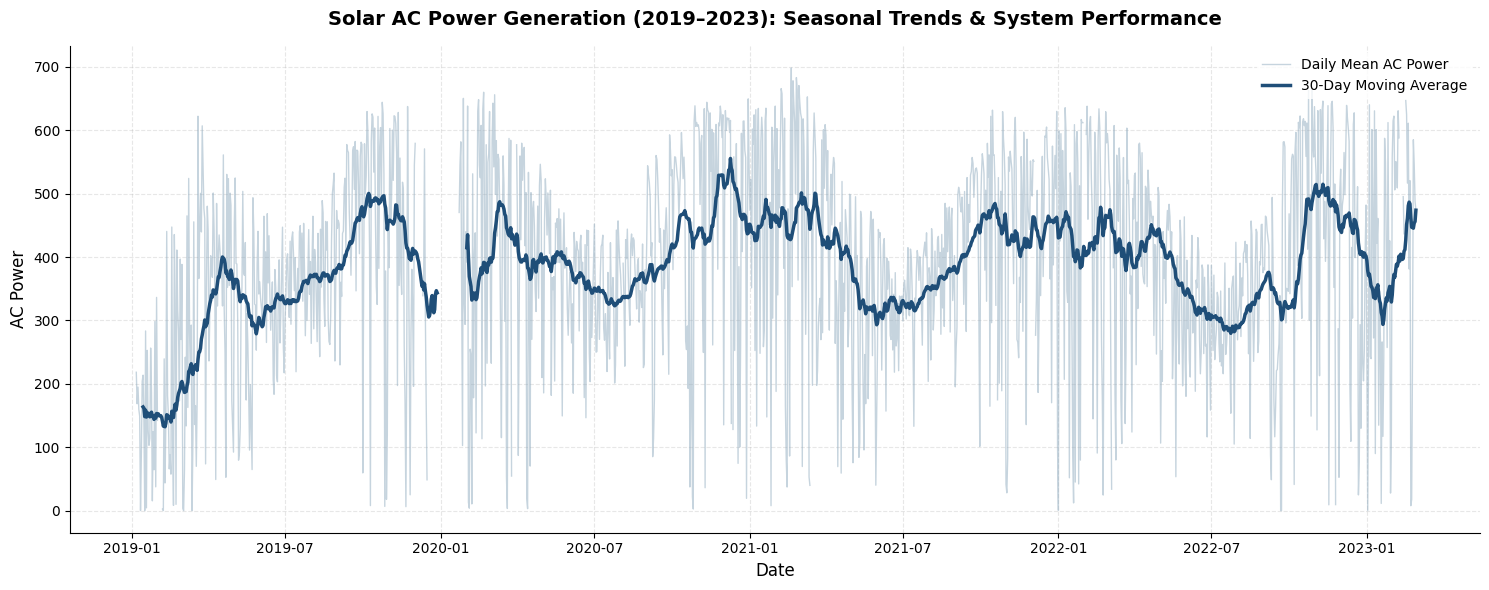

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Clean data & handle datetime index
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Filter out physically impossible negative values
df_clean = df[df['ac_power'] >= 0].copy().sort_values('timestamp')
df_clean.set_index('timestamp', inplace=True)

# 2. Resample to Daily Mean and calculate a 30-day Moving Average
daily_avg = df_clean['ac_power'].resample('D').mean()
rolling_30d = daily_avg.rolling(window=30, min_periods=10).mean()

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(15, 6))

# Plot muted daily points in background
ax.plot(daily_avg.index, daily_avg.values, color='#8faabe', alpha=0.5, linewidth=1, label='Daily Mean AC Power')

# Highlight the 30-day smooth trend
ax.plot(rolling_30d.index, rolling_30d.values, color='#1f4e78', linewidth=2.5, label='30-Day Moving Average')

# 4. Refine Title, Labels & Styling
ax.set_title('Solar AC Power Generation (2019–2023): Seasonal Trends & System Performance',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('AC Power', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

sns.despine()
plt.tight_layout()
plt.show()

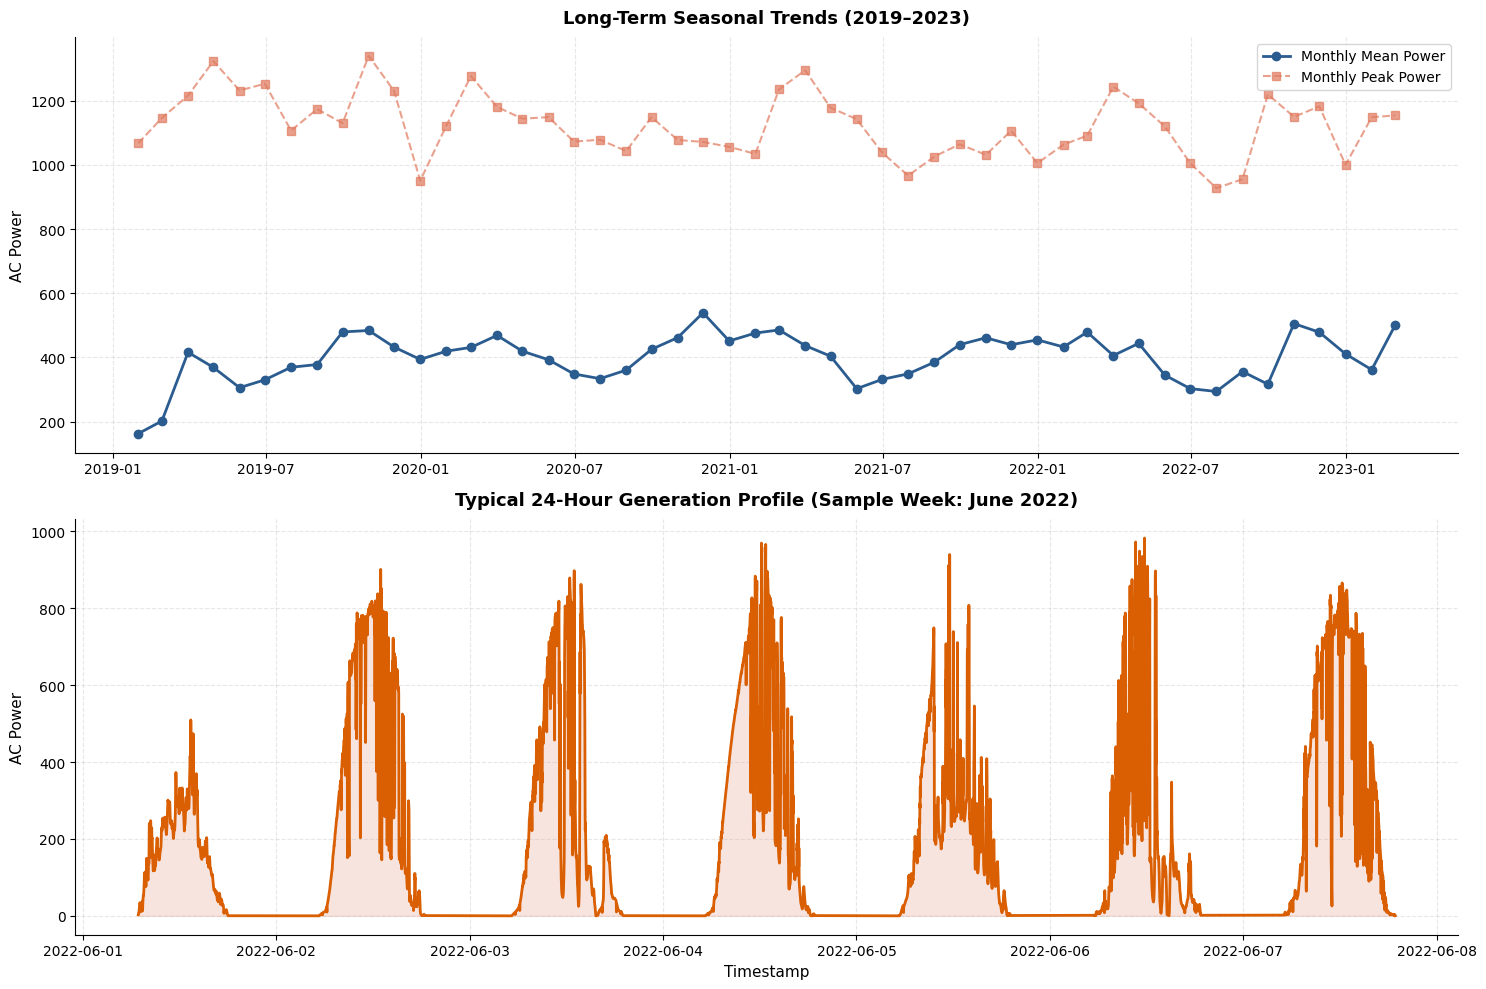

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_clean = df[df['ac_power'] >= 0].copy().sort_values('timestamp').set_index('timestamp')

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ---------------------------------------------------------
# Subplot 1: Long-Term Trend (Monthly Aggregations)
# ---------------------------------------------------------
monthly_max = df_clean['ac_power'].resample('ME').max()
monthly_avg = df_clean['ac_power'].resample('ME').mean()

axes[0].plot(monthly_avg.index, monthly_avg.values, color='#2b5c8f', marker='o', linewidth=2, label='Monthly Mean Power')
axes[0].plot(monthly_max.index, monthly_max.values, color='#e07a5f', linestyle='--', marker='s', alpha=0.7, label='Monthly Peak Power')

axes[0].set_title('Long-Term Seasonal Trends (2019–2023)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('AC Power', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(loc='upper right')

# ---------------------------------------------------------
# Subplot 2: Diurnal Profile (Zoomed-in Sample Week)
# ---------------------------------------------------------
# Slice a representative 7-day summer period
sample_week = df_clean.loc['2022-06-01':'2022-06-07']

axes[1].plot(sample_week.index, sample_week['ac_power'], color='#d95f02', linewidth=2)
axes[1].fill_between(sample_week.index, sample_week['ac_power'], color='#e07a5f', alpha=0.2)

axes[1].set_title('Typical 24-Hour Generation Profile (Sample Week: June 2022)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Timestamp', fontsize=11)
axes[1].set_ylabel('AC Power', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)

# Overall Styling
sns.despine()
plt.tight_layout()
plt.show()

# **Interpretetion from this graph**

* **Daily Pattern (24-Hour Cycle):** Power generation follows a strict day-night bell curve—zero at night, peaking around noon, with sharp mid-day spikes caused by passing cloud cover.

* **Seasonal Trends:** Generation drops every mid-year (July–August) due to monsoon/cloudy weather, and reaches its highest levels during clear winter/spring months.

* **System Capacity:** Peak output consistently caps at 1,200–1,350 units, showing the inverter's maximum physical limit.

* **Data Gaps:** There is a noticeable missing data period around Dec 2019 – Jan 2020, and a low-output startup phase in early 2019 during initial setup.

## **Visualize monthly solar generation to detect seasonal trends over the year.**

In [ ]:
df['ac_power'] = df['ac_power'].clip(lower=0)

In [ ]:
monthly_avg_ac_power = df.groupby('month')['ac_power'].mean().reset_index()


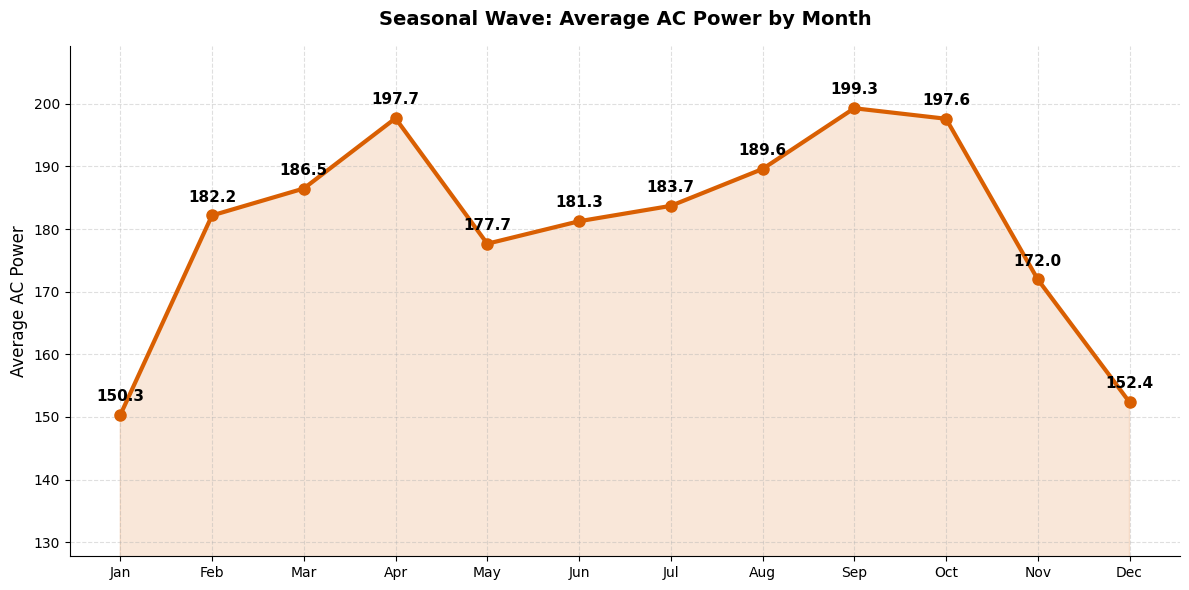

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Extract data
monthly_avg = df.groupby(df['timestamp'].dt.month)['ac_power'].mean().reset_index()
monthly_avg['Month_Name'] = monthly_avg['timestamp'].apply(lambda x: calendar.month_abbr[x])

fig, ax = plt.subplots(figsize=(12, 6))

# 1. Plot the thick continuous line
ax.plot(monthly_avg['Month_Name'], monthly_avg['ac_power'],
        color='#d95f02', marker='o', linewidth=3, markersize=8, label='Monthly Average')

# 2. Fill the area under the curve to emphasize "volume" of power generated
ax.fill_between(monthly_avg['Month_Name'], monthly_avg['ac_power'], color='#d95f02', alpha=0.15)

# 3. Add data labels slightly above the markers
for i, txt in enumerate(monthly_avg['ac_power']):
    ax.annotate(f"{txt:.1f}",
                (monthly_avg['Month_Name'][i], monthly_avg['ac_power'][i]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')

# 4. Aesthetics
ax.set_title('Seasonal Wave: Average AC Power by Month', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Average AC Power', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

# Set Y-axis to start slightly below the minimum value so the wave doesn't float too high
ax.set_ylim(bottom=monthly_avg['ac_power'].min() * 0.85)

sns.despine()
plt.tight_layout()
plt.show()

* **Seasonal Variation:** The ac_power is generally higher during the spring and summer months (April to October), peaking in September and October. It is lowest in the winter months (November, December, January).
* **Peak Production:** Months like September and April show the highest average AC power, indicating optimal conditions for solar energy production during these periods.
* **Lowest Production:** January, November, and December have the lowest average AC power, which is expected due to shorter daylight hours and potentially lower solar irradiance during winter.

### **Visualize year on year Power generation from Panels.**

In [ ]:
df['year'] = df['timestamp'].dt.year
yearly_avg_ac_power = df.groupby('year')['ac_power'].mean().reset_index()
display(yearly_avg_ac_power)

,year,ac_power
0,2019,184.946559
1,2020,188.153672
2,2021,183.784692
3,2022,175.062214
4,2023,155.063797


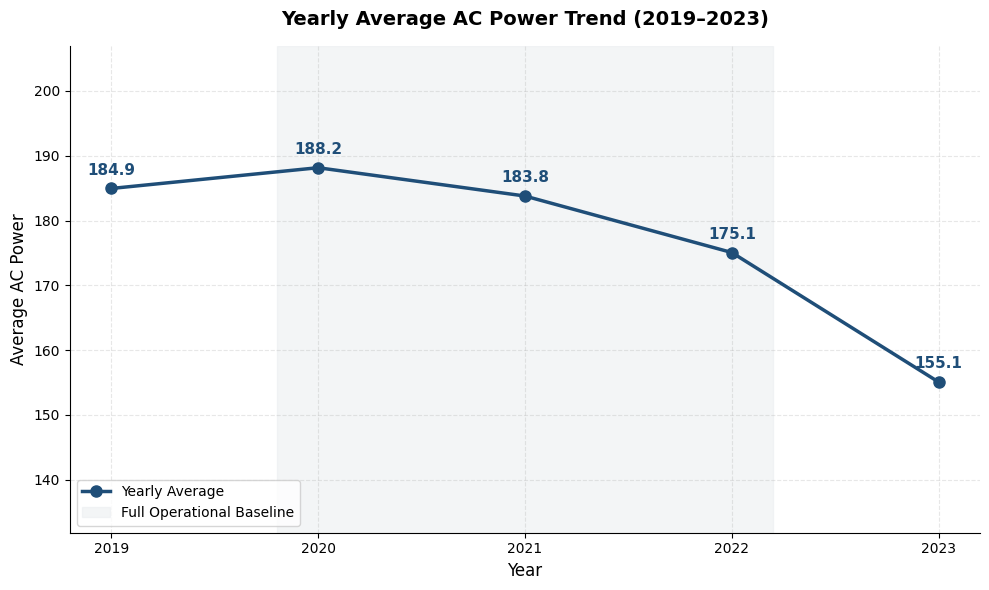

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

# 1. Connect annual points with a clean trend line
ax.plot(
    yearly_avg_ac_power['year'],
    yearly_avg_ac_power['ac_power'],
    color='#1f4e78',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Yearly Average'
)

# 2. Add exact values above each point
for i, row in yearly_avg_ac_power.iterrows():
    ax.annotate(
        f"{row['ac_power']:.1f}",
        (row['year'], row['ac_power']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='#1f4e78'
    )

# 3. Highlight full operational baseline vs partial years
ax.axvspan(2019.8, 2022.2, color='#e9ecef', alpha=0.5, label='Full Operational Baseline')

# 4. Clean styling and labels
ax.set_title('Yearly Average AC Power Trend (2019–2023)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average AC Power', fontsize=12)
ax.set_xticks(yearly_avg_ac_power['year'])

# Adjust Y-limits so annotations fit comfortably
ax.set_ylim(bottom=yearly_avg_ac_power['ac_power'].min() * 0.85, top=yearly_avg_ac_power['ac_power'].max() * 1.1)

ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='lower left', frameon=True)
sns.despine()

plt.tight_layout()
plt.show()

* ### General Trend: The average AC power shows a slight increase from 2019 to 2020, and then a gradual decrease from 2021 to 2023.
* ### Peak Year: 2020 appears to be the year with the highest average AC power production.
* ### Decline in Recent Years: There's a noticeable decline in average AC power from 2021 onwards, with 2023 having the lowest average among the years displayed. beacause degradation in capacity of panels for generation.

## **Correlation Analysis**

Let's examine the correlation between the numerical features in the dataset.

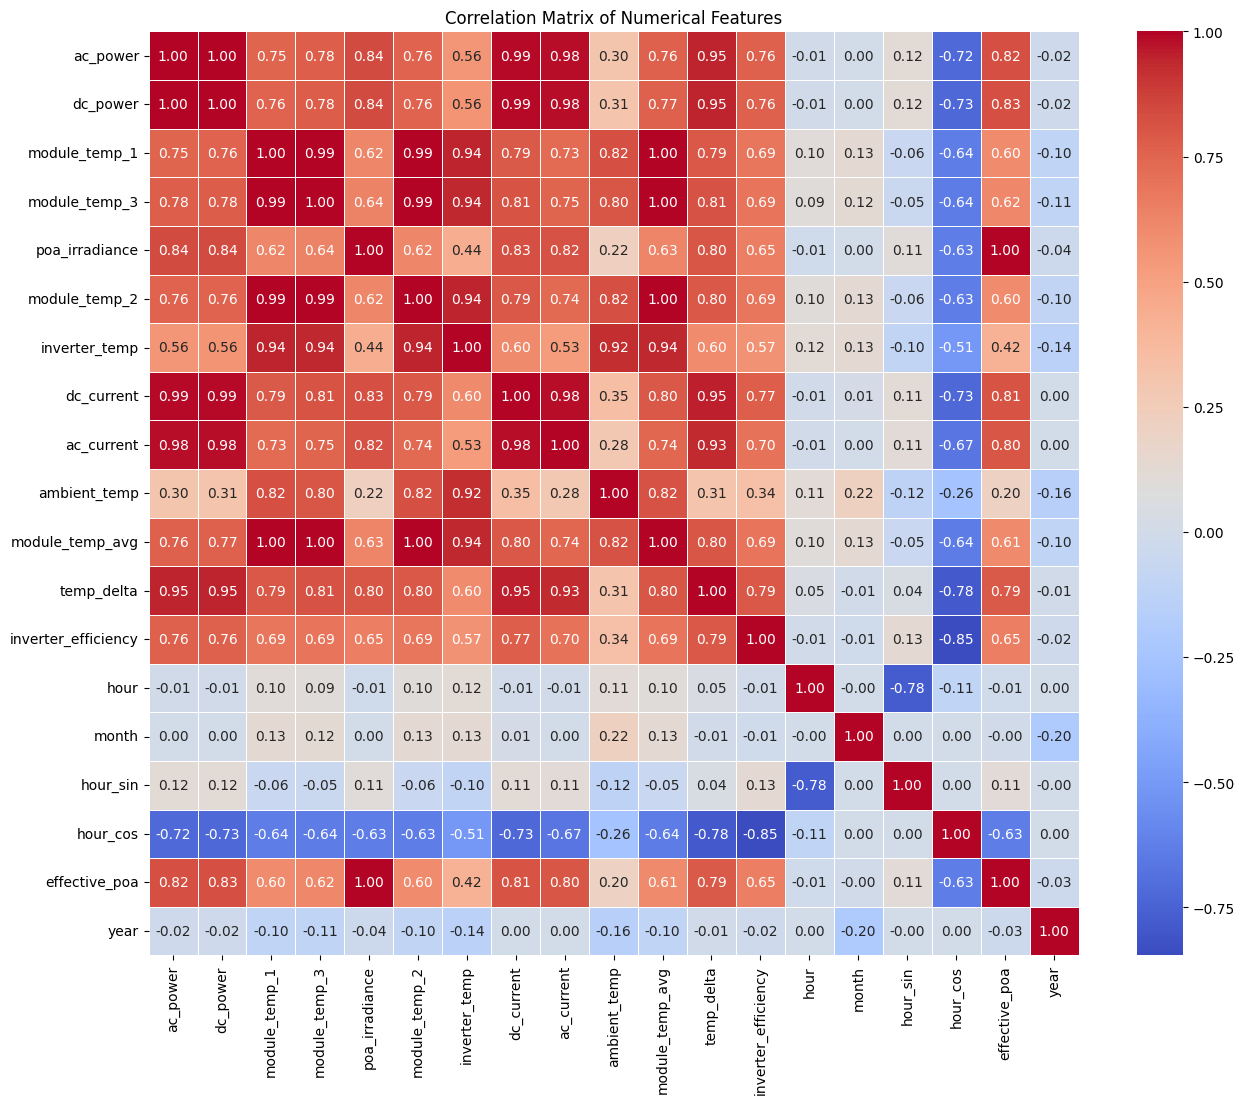

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##**Key Observations from the Correlation Matrix:**

**Strong Positive Correlation with ac_power:**

* **dc_power:** As expected, dc_power shows a very strong positive correlation (0.99) with ac_power, indicating that higher DC power generation directly leads to higher AC power output.
* **module_temp_1, module_temp_2, module_temp_3, and module_temp_avg:** All module temperatures and their average show a strong positive correlation (around 0.75-0.78) with ac_power. This suggests that higher panel temperatures are generally associated with higher AC power production, likely because both increase with solar irradiance.
* **poa_irradiance:** There's a strong positive correlation (0.84) between poa_irradiance (Plane of Array Irradiance) and ac_power, which is fundamental for solar power generation.
* **dc_current and ac_current:** Both current measurements are highly correlated with ac_power (around 0.99 and 0.96 respectively), as current is a direct component of power.
* **inverter_efficiency:** inverter_efficiency also shows a strong positive correlation (0.76) with ac_power, suggesting that more efficient power conversion contributes to higher AC output.
effective_poa: This engineered feature, designed to reflect effective solar production, has a very strong positive correlation (0.86) with ac_power, validating its utility.

**Weak/Negative Correlations with ac_power:**

* **ambient_temp, temp_delta, hour, month, hour_sin, hour_cos, year:** These features generally show weaker or negligible correlations with ac_power directly, although they might influence other factors that affect power indirectly (e.g., month and hour for seasonality and time of day, which are captured by poa_irradiance and temperatures).

### **Ploting Histograms for numerical features to examine distribution of data.**

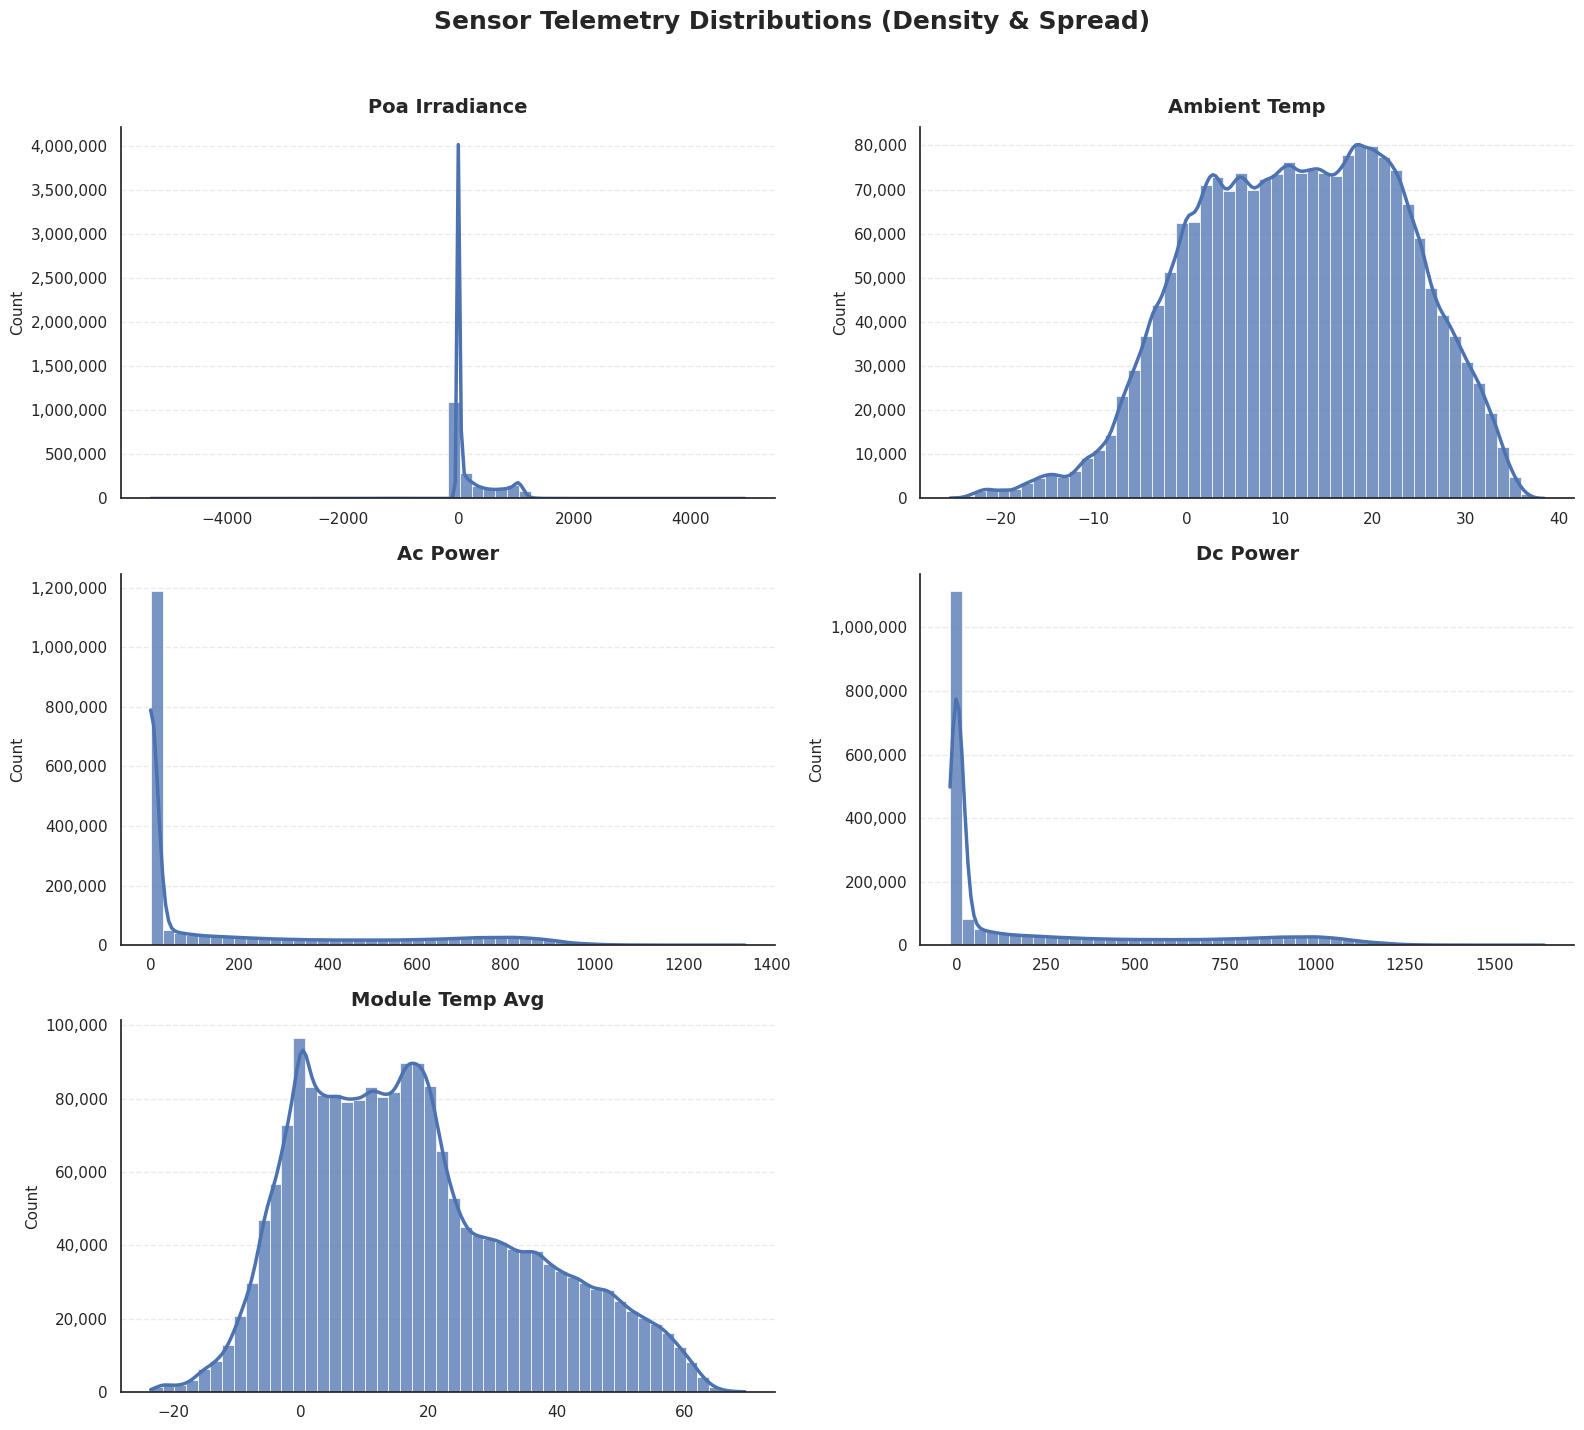

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, modern aesthetic background
sns.set_theme(style="white")

numeric_features = ['poa_irradiance', 'ambient_temp', 'ac_power', 'dc_power', 'module_temp_avg']

# 2. Optional but Recommended: Filter out nighttime (zeros) and bad sensors for a better view
# Uncomment the line below to only plot daylight generation
# df_plot = df[(df['ac_power'] > 0) & (df['poa_irradiance'] >= 0)]
df_plot = df.copy() # Using original dataframe for now

# 3. Generate a distinct color palette for the subplots
#colors = sns.color_palette("husl", len(numeric_features))

# Adjusted figsize for better proportions
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()

# Add a main overarching title
fig.suptitle('Sensor Telemetry Distributions (Density & Spread)', fontsize=18, fontweight='bold', y=1.02)

for i, feature in enumerate(numeric_features):
    # Clean up the feature names for the titles (e.g., 'ac_power' -> 'Ac Power')
    clean_title = feature.replace('_', ' ').title()

    # Generate the histogram
    sns.histplot(
        df_plot[feature],
        bins=50,
        ax=axes[i],
        kde=True,
        #color=colors[i],
        edgecolor='white',      # Replaces harsh black borders with clean white
        linewidth=0.5,
        alpha=0.75,             # Slight transparency looks more modern
        line_kws={'linewidth': 2.5} # Makes the KDE curve thicker and smoother
    )

    # 4. Refine Axes and Labels
    axes[i].set_title(f'{clean_title}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=11)

    # Add soft horizontal grid lines for readability
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

    # Format Y-axis to avoid messy scientific notation (e.g., 1e6 -> 1,000,000)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 5. Hide any unused subplots gracefully
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Remove top and right borders (spines) for a cleaner "open" look
sns.despine()

plt.tight_layout()
plt.show()

* **POA Irradiance** (poa_irradiance): The histogram for POA irradiance is highly skewed, with a very large peak at or near zero. This indicates that a significant portion of the data points corresponds to times when there is little to no solar irradiance (e.g., during the night or heavily cloudy periods). There's a long tail extending to higher values, showing the distribution of solar intensity when the sun is out.
* **Ambient Temperature** (ambient_temp): This histogram shows a roughly bell-shaped distribution, suggesting that ambient temperatures vary across a range, with a peak around 10-20°C, and fewer occurrences of extremely cold or hot temperatures.
* **AC Power (ac_power) and DC Power (dc_power)**: Both AC and DC power histograms show a similar pattern: a very large concentration of values at zero, and then a rapid decrease in frequency as power increases. This is expected, as the solar system generates no power at night.
* **Average Module Temperature** (module_temp_avg): Similar to ambient temperature, the average module temperature shows a distribution with a peak, but it's generally higher than ambient temperature, which is expected as modules heat up when exposed to sunlight.


### **Model Training and Evaluation**
We will split the data chronologically, train an XGBoost model, and evaluate its performance.

### **Forecasting Split: Train until 2022, Test on 2023**
We will now split the data based on the year to see how the model performs on the most recent unseen data.

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Group by date to get daily totals or means
df_daily = df.groupby(df['timestamp'].dt.date).agg({
    'ac_power': 'sum',
    'poa_irradiance': 'sum',
    'ambient_temp': 'mean',
    'module_temp_avg': 'mean',
    'effective_poa': 'sum',
    'month': 'first'
}).reset_index()

df_daily['timestamp'] = pd.to_datetime(df_daily['timestamp'])

# Define features for daily model
daily_features = ['poa_irradiance', 'ambient_temp', 'module_temp_avg', 'effective_poa', 'month']
daily_target = 'ac_power'

# Chronological split: Train until end of 2022, Test on 2023
train_daily = df_daily[df_daily['timestamp'] < '2023-01-01']
test_daily = df_daily[df_daily['timestamp'] >= '2023-01-01']

X_train_d, y_train_d = train_daily[daily_features], train_daily[daily_target]
X_test_d, y_test_d = test_daily[daily_features], test_daily[daily_target]

# Train daily model
model_daily = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_daily.fit(X_train_d, y_train_d)

# Forecast for 2023
y_pred_d = model_daily.predict(X_test_d)

# Metrics
print(f'Daily MAE: {mean_absolute_error(y_test_d, y_pred_d):.2f}')
print(f'Daily R2 Score: {r2_score(y_test_d, y_pred_d):.4f}')

Daily MAE: 14737.49
Daily R2 Score: 0.9660


### **Day-wise Forecasting**
We will now aggregate the data into daily totals to perform day-wise prediction and evaluation.

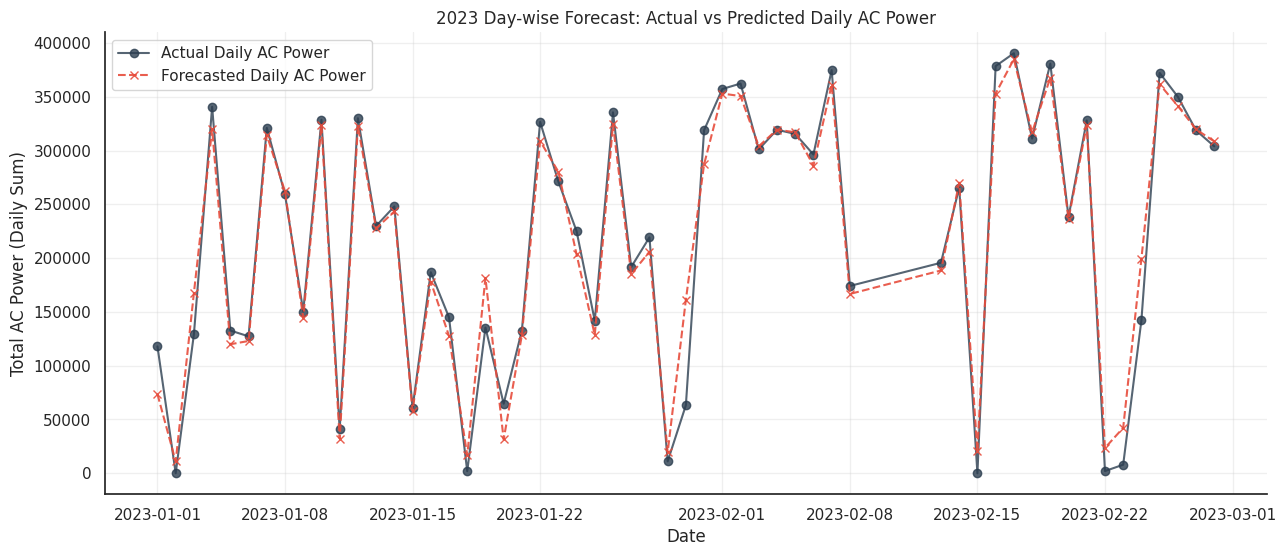

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_daily['timestamp'], y_test_d, label='Actual Daily AC Power', marker='o', alpha=0.8,color='#2c3e50')
plt.plot(test_daily['timestamp'], y_pred_d, label='Forecasted Daily AC Power', marker='x', linestyle='--', alpha=0.9, color='#e74c3c')
plt.title('2023 Day-wise Forecast: Actual vs Predicted Daily AC Power')
plt.xlabel('Date')
plt.ylabel('Total AC Power (Daily Sum)')
plt.legend()
plt.grid(True, alpha=0.3)
# Remove top and right borders
sns.despine()
plt.show()

## Feature Importance for Day-wise Model
Analyzing which variables have the most predictive power for daily AC energy output.

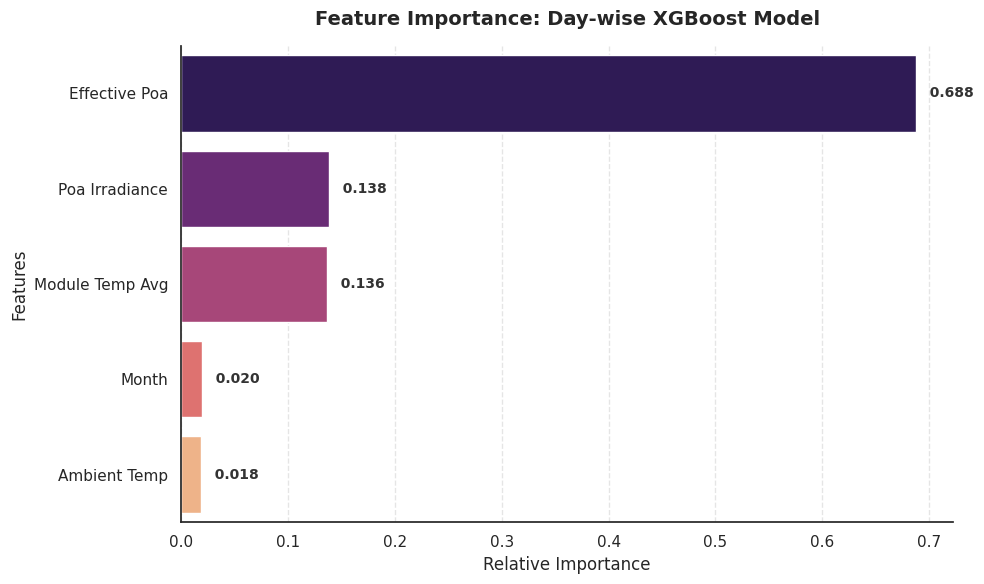

,Feature,Importance
3,effective_poa,0.687900
0,poa_irradiance,0.137953
2,module_temp_avg,0.135988
4,month,0.019705
1,ambient_temp,0.018453


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
importances = model_daily.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': daily_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))

# Clean up feature names for display (e.g., 'module_temp_avg' -> 'Module Temp Avg')
feature_labels = feature_importance_df['Feature'].str.replace('_', ' ').str.title()

ax = sns.barplot(
    x='Importance',
    y=feature_labels,
    data=feature_importance_df,
    palette='magma',
    hue=feature_labels,
    legend=False
)

# Add exact numeric values at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='  %.3f', padding=3, fontsize=10, fontweight='bold', color='#333333')

plt.title('Feature Importance: Day-wise XGBoost Model', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

display(feature_importance_df)

**Feature Importance**

* effective_poa – strongest predictor because it measures the actual solar energy reaching the panels.
* poa_irradiance – also highly relevant but overlaps with effective_poa.
* module_temp_avg – affects panel efficiency, so it meaningfully improves predictions.

##**Future Forecasting**

**To predict future power output, we must feed the model future weather features.**

* We will use Historical Day-of-Year Averages
* Since we already have 4 years of historical data (2019–2022), we will construct a Typical Weather Profile for 2023. For example, to estimate the weather for March 15, 2023, we will take the average weather measured on March 15 across 2019, 2020, 2021, and 2022.

In [ ]:
# Filter historical training data (2019 to 2022)
hist_df = df[df['timestamp'] < '2023-01-01'].copy()

# Group historical data by (Month, Day) to find average weather per calendar day
hist_df['day_of_year'] = hist_df['timestamp'].dt.dayofyear

daily_profile = hist_df.groupby('day_of_year').agg({
    'poa_irradiance': 'sum',
    'ambient_temp': 'mean',
    'module_temp_avg': 'mean',
}).reset_index()

# Recalculate effective_poa for the average weather profiles
daily_profile['effective_poa'] = daily_profile['poa_irradiance'] * (
    1.0 - (daily_profile['module_temp_avg'] - 25).clip(lower=0) * 0.004
)

**BUILD FUTURE FEATURE MATRIX (March 1 - Dec 31, 2023)**

In [ ]:
future_dates = pd.date_range(start='2023-03-01', end='2023-12-31', freq='D')
future_df = pd.DataFrame({'timestamp': future_dates})
future_df['day_of_year'] = future_df['timestamp'].dt.dayofyear
future_df['month'] = future_df['timestamp'].dt.month

# Merge historical daily average weather onto future dates
future_df = future_df.merge(daily_profile, on='day_of_year', how='left')

# Define exact features expected by your trained model_daily
daily_features = ['poa_irradiance', 'ambient_temp', 'module_temp_avg', 'effective_poa', 'month']
X_future = future_df[daily_features]

In [ ]:
future_df['forecasted_ac_power'] = model_daily.predict(X_future)

# Ensure no negative predictions
future_df['forecasted_ac_power'] = future_df['forecasted_ac_power'].clip(lower=0)

In [ ]:
actual_2023 = df_daily[(df_daily['timestamp'] >= '2023-01-01') & (df_daily['timestamp'] < '2023-03-01')].copy()
actual_2023 = actual_2023.rename(columns={'ac_power': 'power'})
actual_2023['type'] = 'Actual'

# Format future predictions
forecast_2023 = future_df[['timestamp', 'forecasted_ac_power']].rename(columns={'forecasted_ac_power': 'power'})
forecast_2023['type'] = 'Forecast'

# Concatenate full year 2023
full_2023 = pd.concat([actual_2023[['timestamp', 'power', 'type']], forecast_2023[['timestamp', 'power', 'type']]])

print(f"Success! Forecasted {len(future_df)} days from March 1 to December 31, 2023.")
print(f"Total Projected Energy (Mar-Dec 2023): {future_df['forecasted_ac_power'].sum():,.2f} kWh/MWh")

Success! Forecasted 306 days from March 1 to December 31, 2023.
Total Projected Energy (Mar-Dec 2023): 81,939,232.00 kWh/MWh


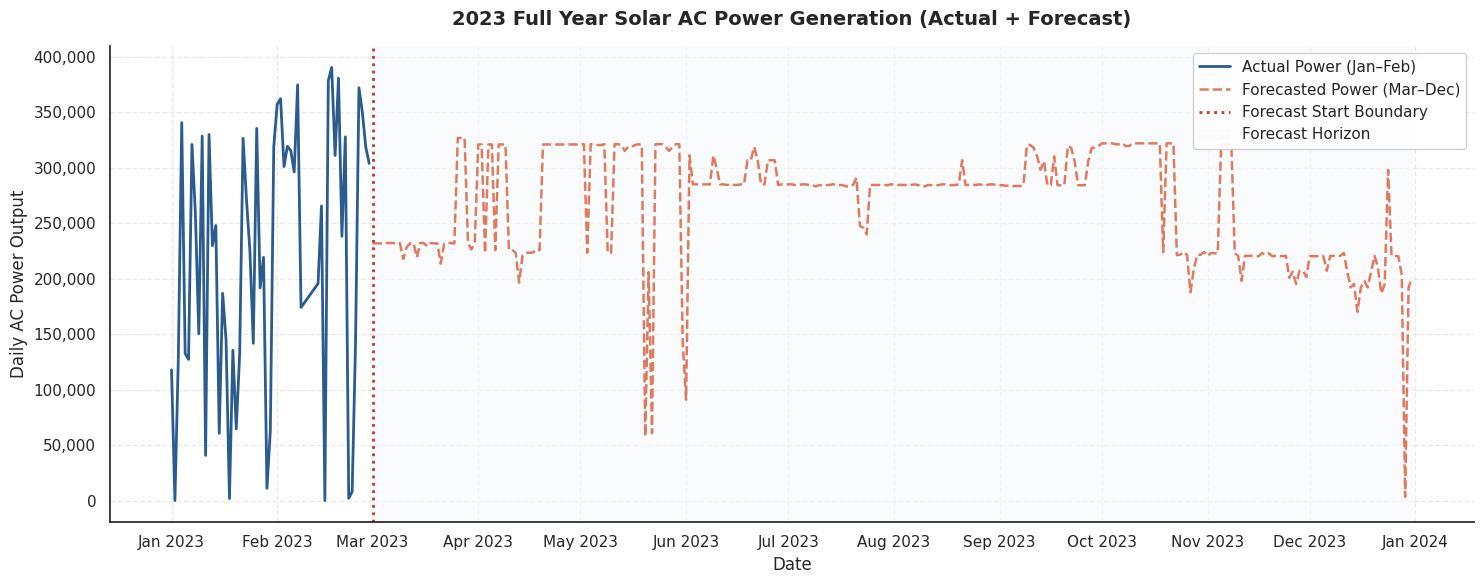

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# Set clean white background theme
sns.set_theme(style="white")

plt.figure(figsize=(15, 6))

# 1. Plot Actuals and Forecast with refined colors and line weights
plt.plot(actual_2023['timestamp'], actual_2023['power'],
         label='Actual Power (Jan–Feb)', color='#2b5c8f', linewidth=2)

plt.plot(forecast_2023['timestamp'], forecast_2023['power'],
         label='Forecasted Power (Mar–Dec)', color='#e07a5f', linestyle='--', linewidth=1.8)

# 2. Forecast Start Boundary Line
boundary_date = pd.to_datetime('2023-03-01')
plt.axvline(x=boundary_date, color='#c0392b', linestyle=':', linewidth=2, label='Forecast Start Boundary')

# 3. Softly shade the forecast region to clearly separate historical data from predictions
plt.axvspan(boundary_date, forecast_2023['timestamp'].max(), color='#f8f9fa', alpha=0.6, label='Forecast Horizon')

# 4. Format Y-Axis with commas (e.g., 300,000 instead of 300000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 5. Format X-Axis to show months clearly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Titles, Labels, and Legend
plt.title('2023 Full Year Solar AC Power Generation (Actual + Forecast)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily AC Power Output', fontsize=12)

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)

# Clean up outer borders
sns.despine()

plt.tight_layout()
plt.show()

##**The Forecast Indicates**
* High energy production during spring and summer.
* Consistent generation through mid-year.
* Reduced production during the final months of the year due to seasonal effects.
* Occasional sharp declines likely caused by adverse weather conditions or anomalous input values.

In [ ]:
df_daily.head()

,timestamp,ac_power,poa_irradiance,ambient_temp,module_temp_avg,effective_poa,month
0,2019-01-03,17463.0,19757.0,0.0,0.900901,19757.0,1
1,2019-01-06,9168.0,6068.0,0.0,2.380952,6068.0,1
2,2019-01-07,10452.0,30022.0,0.0,0.000000,30022.0,1
3,2019-01-08,11111.0,17787.0,0.0,2.479532,17787.0,1
4,2019-01-09,6872.0,11657.0,0.0,0.000000,11657.0,1


In [ ]:
df_daily.columns


Index(['timestamp', 'ac_power', 'poa_irradiance', 'ambient_temp',
       'module_temp_avg', 'effective_poa', 'month'],
      dtype='object')

## Forecasting Using Rolling Method

In [ ]:
df_daily = df_daily.sort_values('timestamp').reset_index(drop=True)

# Lag / rolling features based on ac_power itself
df_daily['power_lag_1'] = df_daily['ac_power'].shift(1)
df_daily['power_lag_2'] = df_daily['ac_power'].shift(2)
df_daily['power_lag_3'] = df_daily['ac_power'].shift(3)
df_daily['power_roll_mean_3'] = df_daily['ac_power'].shift(1).rolling(3).mean()
df_daily['power_roll_mean_7'] = df_daily['ac_power'].shift(1).rolling(7).mean()

df_daily_model = df_daily.dropna().reset_index(drop=True)

lag_features = ['power_lag_1', 'power_lag_2', 'power_lag_3',
                'power_roll_mean_3', 'power_roll_mean_7']

daily_features = ['poa_irradiance', 'ambient_temp', 'module_temp_avg',
                   'effective_poa', 'month'] + lag_features

train_df = df_daily_model[df_daily_model['timestamp'] < '2023-01-01']
X_train = train_df[daily_features]
y_train = train_df['ac_power']

model_daily_rolling = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
)
model_daily_rolling.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
future_dates = pd.date_range(start='2023-03-01', end='2023-12-31', freq='D')
future_df = pd.DataFrame({'timestamp': future_dates})
future_df['day_of_year'] = future_df['timestamp'].dt.dayofyear
future_df['month'] = future_df['timestamp'].dt.month

future_df = future_df.merge(daily_profile, on='day_of_year', how='left')
# future_df now has: timestamp, day_of_year, month, poa_irradiance, ambient_temp,
# module_temp_avg, effective_poa

In [ ]:
import numpy as np

# Seed history with ACTUAL power up to the day before forecasting starts (Jan 1 - Feb 28, 2023)
history_df = df_daily[df_daily['timestamp'] < '2023-03-01'][['timestamp', 'ac_power']]
history_dict = dict(zip(history_df['timestamp'], history_df['ac_power']))

forecast_records = []

for date in future_dates:
    row = future_df[future_df['timestamp'] == date].iloc[0]

    lag_1 = history_dict[date - pd.Timedelta(days=1)]
    lag_2 = history_dict[date - pd.Timedelta(days=2)]
    lag_3 = history_dict[date - pd.Timedelta(days=3)]
    last_3 = [history_dict[date - pd.Timedelta(days=i)] for i in range(1, 4)]
    last_7 = [history_dict[date - pd.Timedelta(days=i)] for i in range(1, 8)]

    X_row = pd.DataFrame([{
        'poa_irradiance':    row['poa_irradiance'],
        'ambient_temp':      row['ambient_temp'],
        'module_temp_avg':   row['module_temp_avg'],
        'effective_poa':     row['effective_poa'],
        'month':             row['month'],
        'power_lag_1':       lag_1,
        'power_lag_2':       lag_2,
        'power_lag_3':       lag_3,
        'power_roll_mean_3': np.mean(last_3),
        'power_roll_mean_7': np.mean(last_7),
    }])[daily_features]

    pred = max(model_daily_rolling.predict(X_row)[0], 0)

    # Feed prediction back into history so the NEXT day's lag features see it
    history_dict[date] = pred
    forecast_records.append({'timestamp': date, 'power': pred})

rolling_forecast_df = pd.DataFrame(forecast_records)
rolling_forecast_df['type'] = 'Forecast (Rolling)'

print(f"Rolling forecast done for {len(rolling_forecast_df)} days.")
print(f"Total projected energy (Mar-Dec 2023): {rolling_forecast_df['power'].sum():,.2f} kWh/MWh")

Rolling forecast done for 306 days.
Total projected energy (Mar-Dec 2023): 79,179,984.00 kWh/MWh


In [ ]:
actual_2023 = df_daily[(df_daily['timestamp'] >= '2023-01-01') & (df_daily['timestamp'] < '2023-03-01')].copy()
actual_2023 = actual_2023.rename(columns={'ac_power': 'power'})
actual_2023['type'] = 'Actual'

full_2023_rolling = pd.concat([
    actual_2023[['timestamp', 'power', 'type']],
    rolling_forecast_df[['timestamp', 'power', 'type']]
])

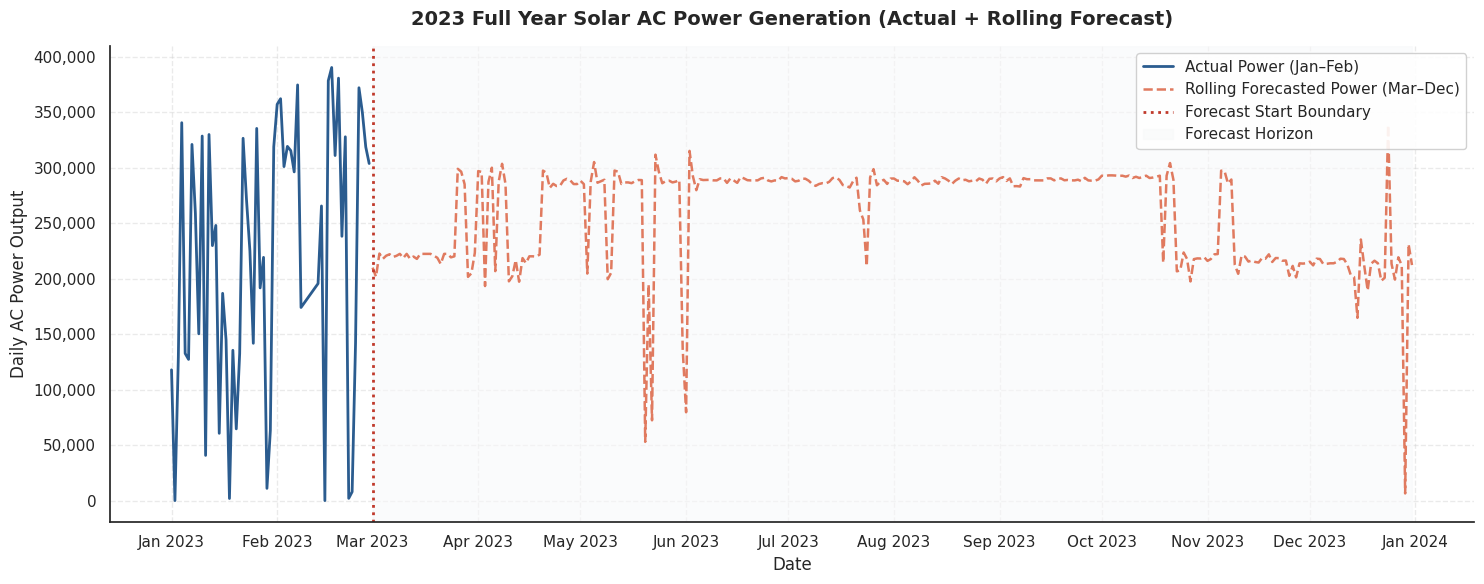

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

sns.set_theme(style="white")

plt.figure(figsize=(15, 6))

# 1. Plot Actuals and Rolling Forecast
plt.plot(actual_2023['timestamp'], actual_2023['power'],
         label='Actual Power (Jan–Feb)', color='#2b5c8f', linewidth=2)

plt.plot(rolling_forecast_df['timestamp'], rolling_forecast_df['power'],
         label='Rolling Forecasted Power (Mar–Dec)', color='#e07a5f', linestyle='--', linewidth=1.8)

# 2. Forecast Start Boundary Line
boundary_date = pd.to_datetime('2023-03-01')
plt.axvline(x=boundary_date, color='#c0392b', linestyle=':', linewidth=2, label='Forecast Start Boundary')

# 3. Softly shade the forecast region
plt.axvspan(boundary_date, rolling_forecast_df['timestamp'].max(), color='#f8f9fa', alpha=0.6, label='Forecast Horizon')

# 4. Format Y-Axis with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 5. Format X-Axis to show months clearly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Titles, Labels, and Legend
plt.title('2023 Full Year Solar AC Power Generation (Actual + Rolling Forecast)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily AC Power Output', fontsize=12)

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

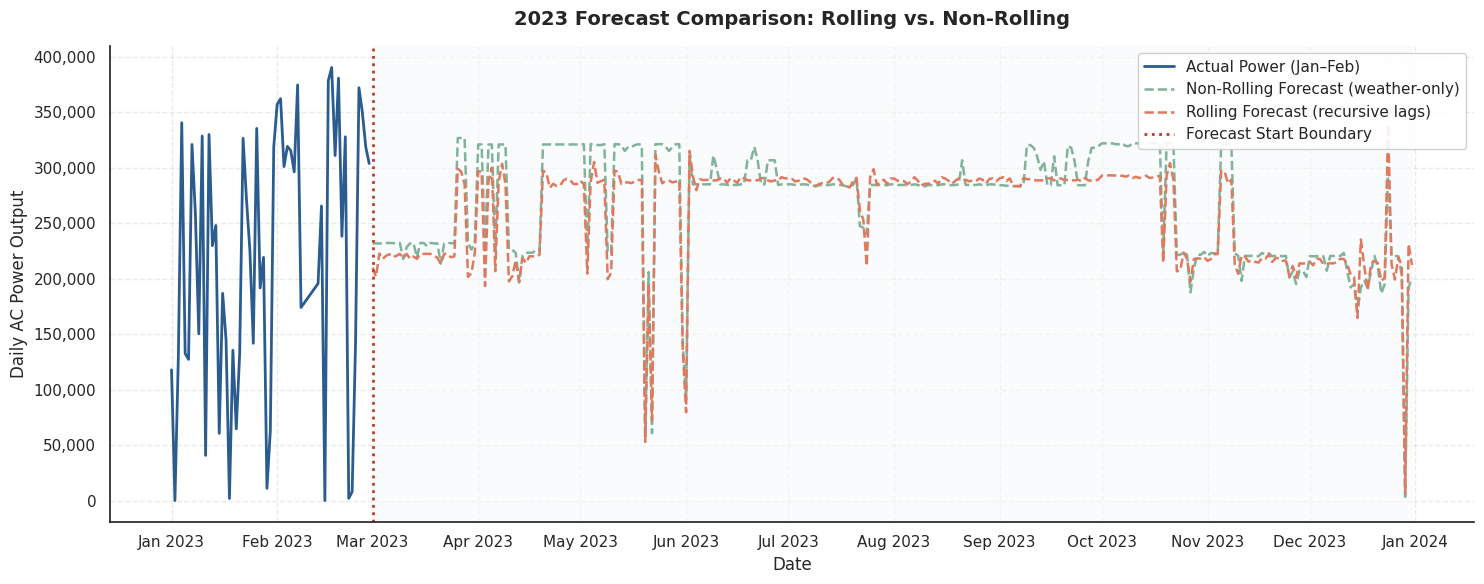

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(actual_2023['timestamp'], actual_2023['power'],
         label='Actual Power (Jan–Feb)', color='#2b5c8f', linewidth=2)

plt.plot(forecast_2023['timestamp'], forecast_2023['power'],
         label='Non-Rolling Forecast (weather-only)', color='#81b29a', linestyle='--', linewidth=1.8)

plt.plot(rolling_forecast_df['timestamp'], rolling_forecast_df['power'],
         label='Rolling Forecast (recursive lags)', color='#e07a5f', linestyle='--', linewidth=1.8)

boundary_date = pd.to_datetime('2023-03-01')
plt.axvline(x=boundary_date, color='#c0392b', linestyle=':', linewidth=2, label='Forecast Start Boundary')
plt.axvspan(boundary_date, rolling_forecast_df['timestamp'].max(), color='#f8f9fa', alpha=0.6)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('2023 Forecast Comparison: Rolling vs. Non-Rolling', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily AC Power Output', fontsize=12)

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

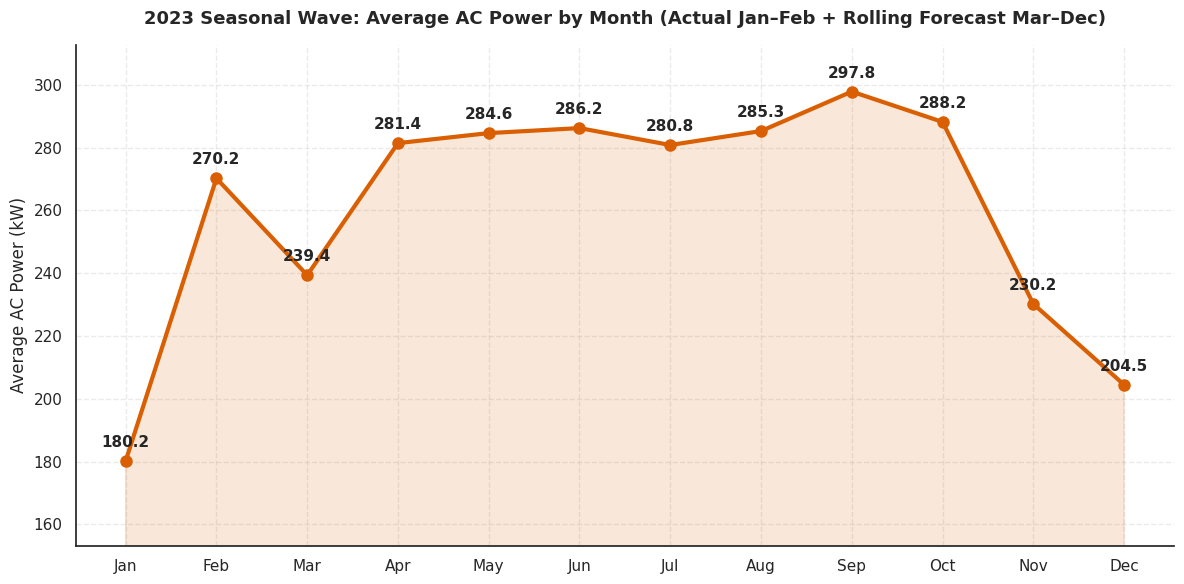

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Combine actual + rolling forecast into one continuous 2023 series
full_2023_rolling = pd.concat([
    actual_2023[['timestamp', 'power']],
    forecast_2023[['timestamp', 'power']]
]).sort_values('timestamp').reset_index(drop=True)

full_2023_rolling['power_kw'] = full_2023_rolling['power'] / 1000

# Monthly average for 2023 (actual + rolling forecast combined), in kW
monthly_avg_2023 = full_2023_rolling.groupby(full_2023_rolling['timestamp'].dt.month)['power_kw'].mean().reset_index()
monthly_avg_2023['Month_Name'] = monthly_avg_2023['timestamp'].apply(lambda x: calendar.month_abbr[x])

fig, ax = plt.subplots(figsize=(12, 6))

# 1. Plot the thick continuous line
ax.plot(monthly_avg_2023['Month_Name'], monthly_avg_2023['power_kw'],
        color='#d95f02', marker='o', linewidth=3, markersize=8, label='Monthly Average')

# 2. Fill the area under the curve to emphasize "volume" of power generated
ax.fill_between(monthly_avg_2023['Month_Name'], monthly_avg_2023['power_kw'], color='#d95f02', alpha=0.15)

# 3. Add data labels slightly above the markers
for i, txt in enumerate(monthly_avg_2023['power_kw']):
    ax.annotate(f"{txt:,.1f}",
                (monthly_avg_2023['Month_Name'][i], monthly_avg_2023['power_kw'][i]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')

# 4. Aesthetics
ax.set_title('2023 Seasonal Wave: Average AC Power by Month (Actual Jan–Feb + Rolling Forecast Mar–Dec)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Average AC Power (kW)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

ax.set_ylim(bottom=monthly_avg_2023['power_kw'].min() * 0.85)

sns.despine()
plt.tight_layout()
plt.show()

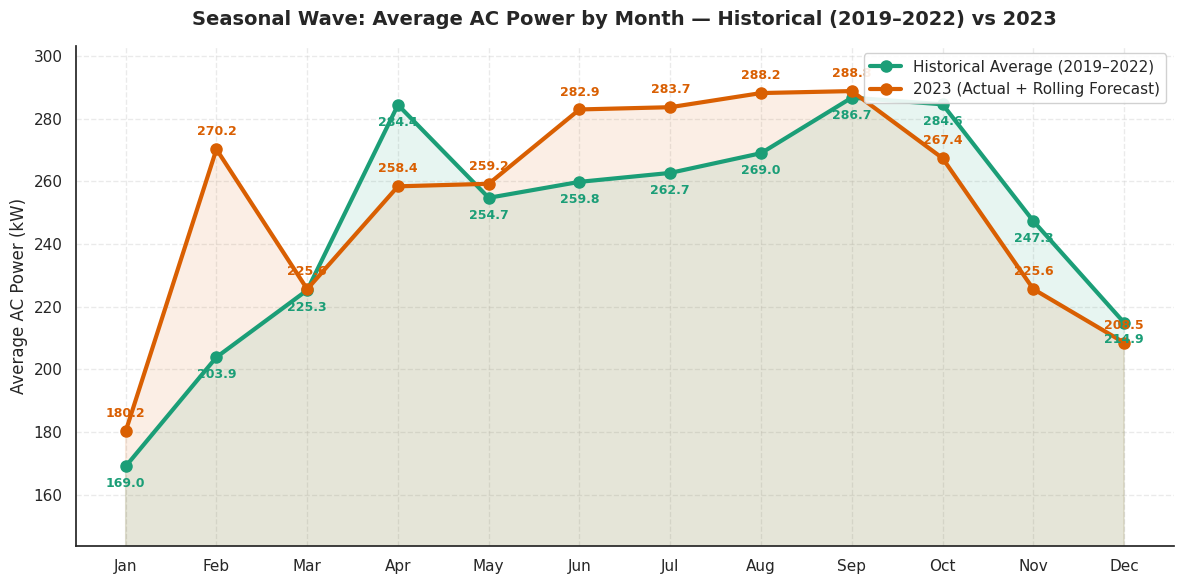

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# --- Historical average (2019-2022), using df_daily (same granularity as 2023 data) ---
hist_2019_2022 = df_daily[df_daily['timestamp'] < '2023-01-01'].copy()
hist_2019_2022['power_kw'] = hist_2019_2022['ac_power'] / 1000  # adjust unit if needed

monthly_avg_hist = hist_2019_2022.groupby(hist_2019_2022['timestamp'].dt.month)['power_kw'].mean().reset_index()
monthly_avg_hist['Month_Name'] = monthly_avg_hist['timestamp'].apply(lambda x: calendar.month_abbr[x])

# --- 2023 series (Actual Jan-Feb + Rolling Forecast Mar-Dec) ---
full_2023_rolling = pd.concat([
    actual_2023[['timestamp', 'power']],
    rolling_forecast_df[['timestamp', 'power']]
]).sort_values('timestamp').reset_index(drop=True)

full_2023_rolling['power_kw'] = full_2023_rolling['power'] / 1000

monthly_avg_2023 = full_2023_rolling.groupby(full_2023_rolling['timestamp'].dt.month)['power_kw'].mean().reset_index()
monthly_avg_2023['Month_Name'] = monthly_avg_2023['timestamp'].apply(lambda x: calendar.month_abbr[x])

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_avg_hist['Month_Name'], monthly_avg_hist['power_kw'],
        color='#1b9e77', marker='o', linewidth=3, markersize=8, label='Historical Average (2019–2022)')
ax.fill_between(monthly_avg_hist['Month_Name'], monthly_avg_hist['power_kw'], color='#1b9e77', alpha=0.10)

ax.plot(monthly_avg_2023['Month_Name'], monthly_avg_2023['power_kw'],
        color='#d95f02', marker='o', linewidth=3, markersize=8, label='2023 (Actual + Rolling Forecast)')
ax.fill_between(monthly_avg_2023['Month_Name'], monthly_avg_2023['power_kw'], color='#d95f02', alpha=0.10)

for i, txt in enumerate(monthly_avg_hist['power_kw']):
    ax.annotate(f"{txt:,.1f}", (monthly_avg_hist['Month_Name'][i], monthly_avg_hist['power_kw'][i]),
                textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9, color='#1b9e77', fontweight='bold')

for i, txt in enumerate(monthly_avg_2023['power_kw']):
    ax.annotate(f"{txt:,.1f}", (monthly_avg_2023['Month_Name'][i], monthly_avg_2023['power_kw'][i]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, color='#d95f02', fontweight='bold')

ax.set_title('Seasonal Wave: Average AC Power by Month — Historical (2019–2022) vs 2023',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average AC Power (kW)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
ax.set_ylim(bottom=min(monthly_avg_hist['power_kw'].min(), monthly_avg_2023['power_kw'].min()) * 0.85)

sns.despine()
plt.tight_layout()
plt.show()